# investment plots

2021-07-11

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import mplfinance as mpf

## Read data from Stooq

https://stooq.com/db/h/

In [2]:
arkw = pd.read_csv('../stooq/hourly/us/nyse_etfs/1/arkw.us.txt', skipinitialspace=True)

In [3]:
arkw.head()

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>,<OPENINT>
0,ARKW.US,60,20200914,160000,101.890,102.500,101.210,102.32,72509,0
1,ARKW.US,60,20200914,170000,102.390,103.036,102.185,102.63,56508,0
2,ARKW.US,60,20200914,180000,102.640,103.047,102.355,102.94,40615,0
3,ARKW.US,60,20200914,190000,102.895,103.281,102.350,102.62,40068,0
4,ARKW.US,60,20200914,200000,102.631,102.790,101.660,102.49,39169,0


In [4]:
def calc_date_str(x):
    year = np.floor(x['<DATE>'] / 10000)
    month = np.floor((x['<DATE>'] % 10000) / 100)
    day = np.floor((x['<DATE>'] % 100))
    hours = np.floor(x['<TIME>'] / 10000)
    minutes = np.floor((x['<TIME>'] % 10000) / 100)
    seconds = np.floor((x['<TIME>'] % 100))
    s = '%i-%02i-%02i %02i:%02i:%02i' % (year, month, day, hours, minutes, seconds)
    return s

In [5]:
def clean_stooq_df(df):
    _df = df.drop(['<TICKER>', '<PER>', '<OPENINT>'], axis=1)
    _df['Date'] = _df.apply(calc_date_str, axis=1)
    _df['Date'] = pd.to_datetime(_df['Date'])
    _df = _df.drop(['<DATE>', '<TIME>'], axis=1)
    _df = _df.rename(columns={'<OPEN>': 'Open', '<HIGH>': 'High', '<LOW>': 'Low', '<CLOSE>': 'Close', '<VOL>': 'Volume' })
#    _df = _df.reindex(columns=['Date', 'Open', 'High', 'Low', 'Close', 'Vol'])
    _df.index = _df['Date']
    _df = _df.drop('Date', axis=1)
    return _df

In [6]:
df = clean_stooq_df(arkw)

In [7]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-09-14 16:00:00,101.890,102.500,101.210,102.32,72509
2020-09-14 17:00:00,102.390,103.036,102.185,102.63,56508
2020-09-14 18:00:00,102.640,103.047,102.355,102.94,40615
2020-09-14 19:00:00,102.895,103.281,102.350,102.62,40068
2020-09-14 20:00:00,102.631,102.790,101.660,102.49,39169


In [8]:
#mystyle = mpf.make_mpf_style(base_mpl_style='seaborn-deep')

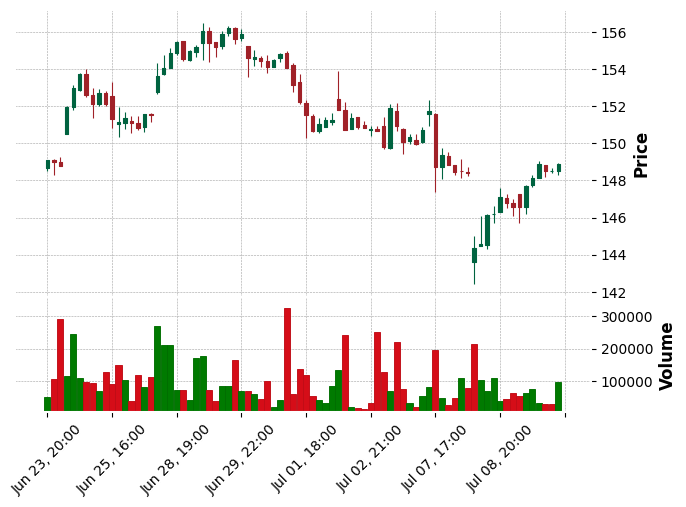

In [9]:
mpf.plot(df.tail(80), type='candle', volume=True, style='charles')